
 Randomly Generated Heuristics:
Node A: 18
Node B: 4
Node C: 20
Node D: 20
Node E: 18
Node F: 12
Node G: 17
Node H: 9
Node I: 10
Node J: 4
Node K: 12
Node L: 9
Node M: 19
Node N: 4

 Shortest Path from K to C: ['K', 'E', 'B', 'A', 'C']


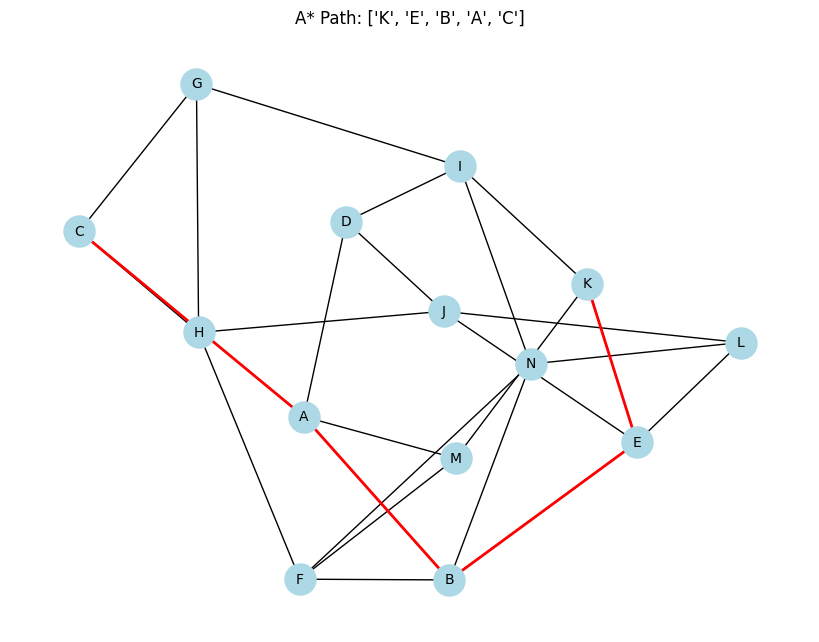

In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import heapq

# Read Graph from CSV
def read_graph(csv_file):
    data = pd.read_csv(csv_file)
    graph = {}
    for _, row in data.iterrows():
        start, end, weight = row['start_node'], row['end_node'], row['weight']
        graph.setdefault(start, []).append((end, weight))
        graph.setdefault(end, []).append((start, weight))
    return graph

# Generate Random Heuristics
def generate_heuristics(graph):
    return {node: random.randint(1, 20) for node in graph}

# A* Algorithm
def astar(graph, heuristics, start, end):
    open_set = [(0, start)]  # (f_score, node)
    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0
    came_from = {}

    while open_set:
        _, current = heapq.heappop(open_set)  # Get node with smallest f_score

        if current == end:
            # Reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            return [start] + path[::-1]

        for neighbor, cost in graph[current]:
            new_cost = g_score[current] + cost
            if new_cost < g_score[neighbor]:
                g_score[neighbor] = new_cost
                f_score = new_cost + heuristics[neighbor]
                came_from[neighbor] = current
                heapq.heappush(open_set, (f_score, neighbor))

    return None  # No path found

# Plot Graph with Path
def plot_graph(graph, path):
    G = nx.Graph()
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors:
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 6))

    # Draw full graph
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10)

    # Highlight shortest path
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
        plt.title(f"A* Path: {path}")
    else:
        plt.title("No path found")

    plt.show()

# Execution
file_path = 'updated_graph_nodes_v2.csv'

# Read graph and generate heuristics
graph = read_graph(file_path)
heuristics = generate_heuristics(graph)

# Show generated heuristics
print("\n Randomly Generated Heuristics:")
for node, value in heuristics.items():
    print(f"Node {node}: {value}")

# Get start and end nodes from user
start_node = input("\nEnter Start Node: ")
end_node = input("Enter End Node: ")

# Find shortest path using A*
path = astar(graph, heuristics, start_node, end_node)

# Show result
if path:
    print(f"\n Shortest Path from {start_node} to {end_node}: {path}")
else:
    print("\n No path found")

# Plot Graph
plot_graph(graph, path)
